# Student Performance Analysis using Machine Learning

## Objective
The goal of this project is to analyze student performance and build predictive models using regression, classification, clustering, and association rule mining techniques.

## Dataset
This project uses the UCI Student Performance dataset, which includes demographic, academic, and behavioral attributes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('data/student-por.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
# Check missing values
df.isnull().sum()

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

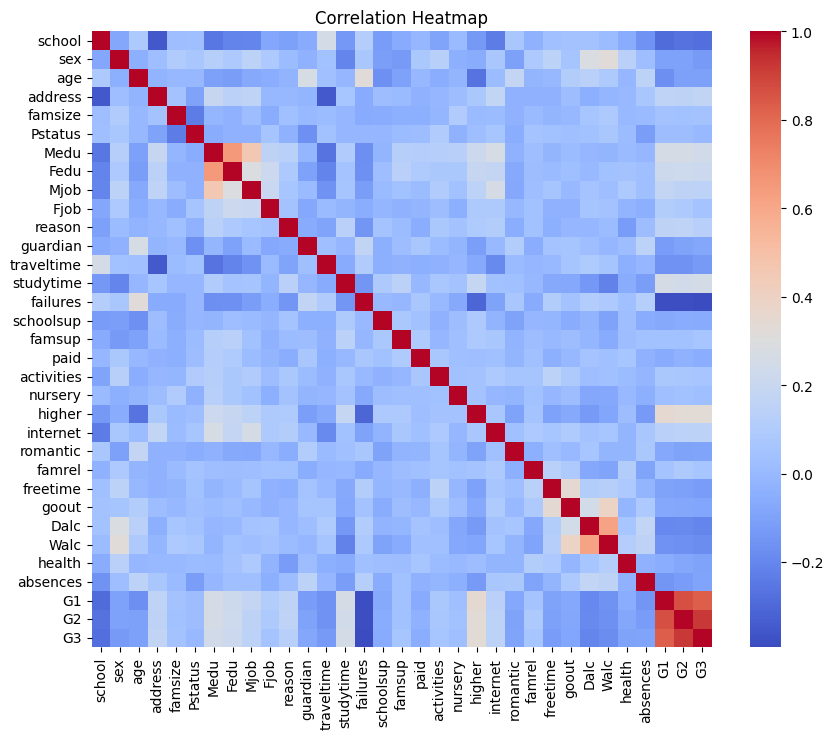

In [4]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

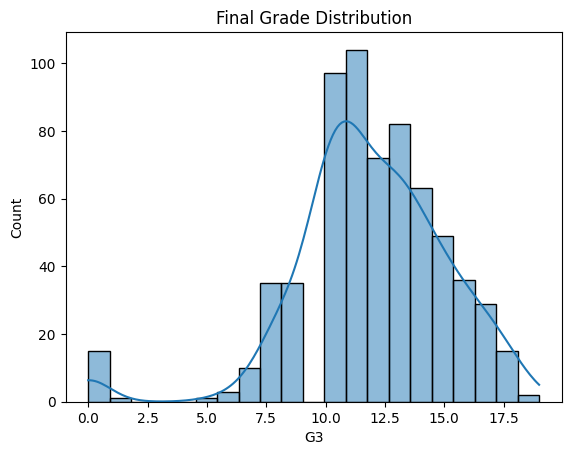

In [5]:
sns.histplot(df['G3'], kde=True)
plt.title("Final Grade Distribution")
plt.show()

In [6]:
X = df.drop('G3', axis=1)
y = df['G3']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.8202961916526714
MSE: 1.3093921278041443


In [9]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("R2:", r2_score(y_test, y_pred_ridge))

R2: 0.8203297315788527


In [10]:
scores = cross_val_score(lr, X, y, cv=5)
print("Cross-validation score:", scores.mean())

Cross-validation score: 0.7977397593025473


In [11]:
# Create grade categories (this part is CORRECT)
df['G3_class'] = pd.cut(
    df['G3'],
    bins=[-1, 10, 15, 20],
    labels=[0, 1, 2]
)

# Features and target
X_class = df.drop(['G3', 'G3_class'], axis=1)
y_class = df['G3_class'].astype(int)

# 🔥 NEW: split the data
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_class, y_train_class)

# Predict on TEST data (not training data)
y_pred = dt.predict(X_test_class)

# Evaluation
print("Accuracy:", accuracy_score(y_test_class, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_class, y_pred))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred))

Accuracy: 0.8307692307692308

Confusion Matrix:
 [[23  9  0]
 [ 5 66  5]
 [ 0  3 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.72      0.77        32
           1       0.85      0.87      0.86        76
           2       0.79      0.86      0.83        22

    accuracy                           0.83       130
   macro avg       0.82      0.82      0.82       130
weighted avg       0.83      0.83      0.83       130



In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_class, y_train_class)

y_pred_knn = knn.predict(X_test_class)

print("KNN Accuracy:", accuracy_score(y_test_class, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_class, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_knn))

KNN Accuracy: 0.7923076923076923

Confusion Matrix:
 [[23  9  0]
 [ 5 65  6]
 [ 1  6 15]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75        32
           1       0.81      0.86      0.83        76
           2       0.71      0.68      0.70        22

    accuracy                           0.79       130
   macro avg       0.77      0.75      0.76       130
weighted avg       0.79      0.79      0.79       130



In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

C:\Users\nasse\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


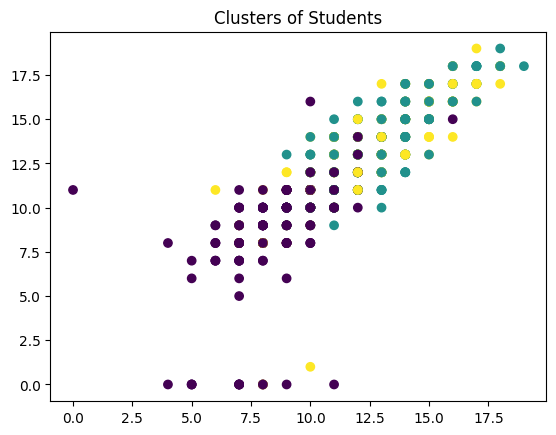

In [14]:
plt.scatter(df['G1'], df['G3'], c=clusters)
plt.title("Clusters of Students")
plt.show()

In [15]:
from mlxtend.frequent_patterns import apriori, association_rules

# Step 1: Keep only numeric columns
df_num = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Convert to binary (above/below median)
df_bin = df_num.apply(lambda col: col > col.median())

# Convert True/False → 1/0
df_bin = df_bin.astype(int)

# Step 3: Apply Apriori
freq_items = apriori(df_bin, min_support=0.1, use_colnames=True)

# Step 4: Generate rules
rules = association_rules(freq_items, metric="lift", min_threshold=1)

# Show results
rules.head()

C:\Users\nasse\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(school),(age),0.348228,0.278891,0.112481,0.323009,1.158192,1.0,0.015363,1.065168,0.209560,0.218563,0.061181,0.363162
1,(age),(school),0.278891,0.348228,0.112481,0.403315,1.158192,1.0,0.015363,1.092322,0.189410,0.218563,0.084519,0.363162
2,(school),(famsize),0.348228,0.295840,0.107858,0.309735,1.046967,1.0,0.004839,1.020130,0.068828,0.201149,0.019732,0.337159
3,(famsize),(school),0.295840,0.348228,0.107858,0.364583,1.046967,1.0,0.004839,1.025739,0.063707,0.201149,0.025094,0.337159
4,(school),(Fjob),0.348228,0.334361,0.120185,0.345133,1.032217,1.0,0.003751,1.016449,0.047887,0.213699,0.016183,0.352290


## Association Rule Insights

- Certain patterns show that low study time is associated with lower grades
- Students with better academic habits tend to cluster together
- These patterns can help identify at-risk students early

## Key Insights

- Strong correlation between early grades and final grade
- Study time positively impacts performance
- Clustering identified distinct student groups
- Classification models successfully categorized performance levels

## Conclusion

Machine learning techniques can help identify at-risk students and improve educational outcomes.